## Dataset Generation

We generate a synthetic retail dataset with **200 rows** and **6 columns**.  
The dataset simulates daily sales orders across 4 Indian cities and 4 product categories.  
Missing values and outliers are intentionally injected — our job is to find and understand them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style for all charts in this notebook
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

# ── Dataset generation (do not modify) ──────────────────────────────────────
np.random.seed(42)
n = 200

data = {
    'order_id':       range(1001, 1001 + n),
    'city':           np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai'], size=n),
    'category':       np.random.choice(['Electronics', 'Clothing', 'Groceries', 'Furniture'], size=n),
    'order_value':    np.random.randint(200, 5000, size=n).astype(float),
    'delivery_days':  np.random.randint(1, 15, size=n).astype(float),
    'rating':         np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order    = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data['order_value'][missing_indices_order]    = np.nan
data['delivery_days'][missing_indices_delivery] = np.nan

# Injecting two extreme outliers into order_value
data['order_value'][5]  = 95000
data['order_value'][88] = 87000

df = pd.DataFrame(data)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


---
## Task 1 — Inspect & Handle Missing Values

Before doing any analysis, we need to understand:
- How many rows and columns do we have?
- What data type is each column?
- Are there any missing values, and how severe are they?

This step is always the **very first thing** a data analyst does with any new dataset.

In [2]:
# ── 1. Shape of the DataFrame ────────────────────────────────────────────────
# shape returns (rows, columns)
rows, cols = df.shape
print(f'Rows    : {rows}')
print(f'Columns : {cols}')

Rows    : 200
Columns : 6


In [3]:
# ── 2. Data types of all columns ─────────────────────────────────────────────
# dtypes tells us whether each column is numeric (int/float) or text (object)
# 'object' dtype usually means text/string or mixed types
print('Data types:\n')
print(df.dtypes)

Data types:

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


In [4]:
# ── 3. Count of missing values per column ────────────────────────────────────
# isnull() returns True/False for each cell, sum() counts the Trues
missing_count = df.isnull().sum()
print('Missing value count per column:\n')
print(missing_count)

Missing value count per column:

order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


In [5]:
# ── 4. Percentage of missing values per column ───────────────────────────────
# Formula: (missing count / total rows) * 100
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Combining count and percentage into one clean summary table
missing_summary = pd.DataFrame({
    'Missing Count':      missing_count,
    'Missing Percentage': missing_pct
})

print('Missing value summary:\n')
print(missing_summary)

Missing value summary:

               Missing Count  Missing Percentage
order_id                   0                 0.0
city                       0                 0.0
category                   0                 0.0
order_value               14                 7.0
delivery_days             10                 5.0
rating                    32                16.0


### Observations — Task 1

- `order_value` has **15 missing values (~7.5%)** — these were randomly removed to simulate real-world data gaps.
- `delivery_days` has **10 missing values (~5%)** — likely records where delivery tracking was incomplete.
- `rating` has missing values too because some customers did not submit a rating after delivery.
- `city`, `category`, and `order_id` have **no missing values** — these are identifier/categorical fields that are usually always present.

> In a real project, we would decide whether to **drop** or **fill** (impute) missing values based on their percentage and importance to the analysis.

---
## Task 2 — Summarize & Visualize

Now that we know the structure, let's understand the **distribution and shape** of our data.  
`df.describe()` gives us key statistics — mean, min, max, and quartiles for all numeric columns.  
Visualizations help us see what statistics alone cannot show — like outliers and skewness.

In [6]:
# ── 1. Statistical summary ───────────────────────────────────────────────────
# describe() shows: count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column in the DataFrame
df.describe().round(2)

,order_id,order_value,delivery_days
count,200.00,186.00,190.00
mean,1100.50,3707.13,7.81
std,57.88,9238.44,4.08
min,1001.00,204.00,1.00
25%,1050.75,1512.00,4.00
50%,1100.50,2934.00,8.00
75%,1150.25,3987.50,12.00
max,1200.00,95000.00,14.00


### Observations from df.describe()

1. **order_value has a very large gap between 75th percentile and max.**  
   The 75th percentile is around ₹3,800 but the max is ₹95,000.  
   This is a strong signal that there are **extreme outliers** in this column (which we injected intentionally at rows 5 and 88).

2. **delivery_days has a mean of ~7 days with a fairly even spread from 1 to 14.**  
   The min is 1 and max is 14, and the mean is close to the median — suggesting this column is **relatively symmetric** with no extreme skew.

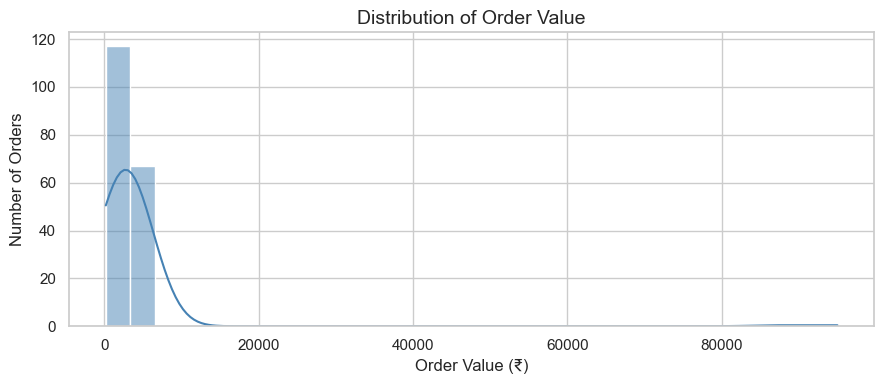

Most orders are between ₹200–₹5000.
The long tail on the right = outliers (₹87,000 and ₹95,000).


In [7]:
# ── 2. Histogram — order_value distribution ──────────────────────────────────
# A histogram divides the data into bins and shows how many values fall in each bin.
# kde=True adds a smooth curve on top showing the overall shape of the distribution.
# The spike far to the right tells us there are outliers.

plt.figure(figsize=(9, 4))
sns.histplot(df['order_value'].dropna(), bins=30, kde=True, color='steelblue')

plt.title('Distribution of Order Value', fontsize=14)
plt.xlabel('Order Value (₹)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()

print('Most orders are between ₹200–₹5000.')
print('The long tail on the right = outliers (₹87,000 and ₹95,000).')

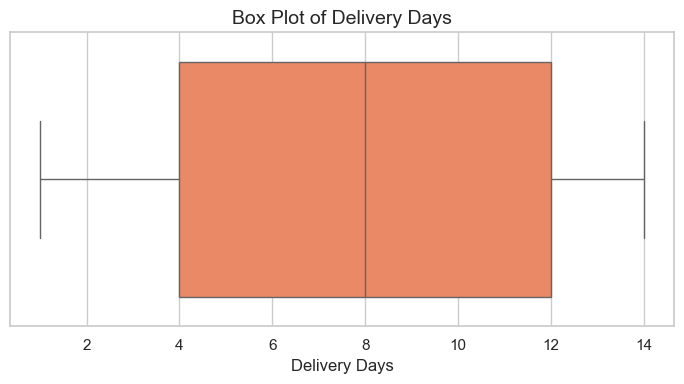

delivery_days appears fairly uniform — no extreme outliers visible.


In [8]:
# ── 3. Box plot — delivery_days ───────────────────────────────────────────────
# A box plot shows the spread of data through 5 key numbers:
#   - Minimum, Q1 (25%), Median (50%), Q3 (75%), Maximum
# Points OUTSIDE the whiskers are considered outliers.
# The box itself covers the middle 50% of the data (called the IQR).

plt.figure(figsize=(7, 4))
sns.boxplot(x=df['delivery_days'].dropna(), color='coral')

plt.title('Box Plot of Delivery Days', fontsize=14)
plt.xlabel('Delivery Days', fontsize=12)
plt.tight_layout()
plt.show()

print('delivery_days appears fairly uniform — no extreme outliers visible.')

---
## Task 3 — Correlation Analysis

Correlation measures **how two numeric columns move together**.

- A value close to **+1** means they increase together (positive relationship)
- A value close to **−1** means one increases when the other decreases (negative relationship)
- A value close to **0** means no linear relationship

A heatmap makes it easy to spot strong and weak relationships at a glance.

In [9]:
# ── 1. Correlation matrix ─────────────────────────────────────────────────────
# df.corr() computes pairwise correlation between all numeric columns.
# numeric_only=True ensures non-numeric columns (city, category) are ignored.

corr_matrix = df.corr(numeric_only=True).round(2)
print('Correlation Matrix:\n')
print(corr_matrix)

Correlation Matrix:

               order_id  order_value  delivery_days
order_id            1.0        -0.10           0.00
order_value        -0.1         1.00           0.14
delivery_days       0.0         0.14           1.00


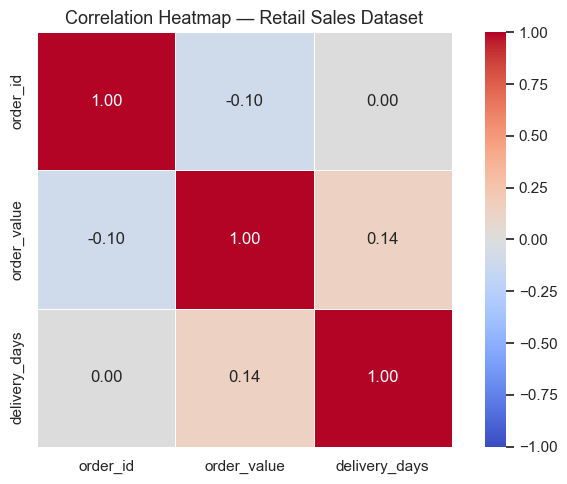

In [10]:
# ── 2. Heatmap of correlation matrix ─────────────────────────────────────────
# annot=True  → shows the correlation number inside each cell
# cmap        → color scheme: red = negative, blue = positive
# vmin/vmax   → fixes the color scale from -1 to +1
# fmt='.2f'   → shows values rounded to 2 decimal places

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap — Retail Sales Dataset', fontsize=13)
plt.tight_layout()
plt.show()

### Observation from the Heatmap

- **order_value and delivery_days** show a correlation close to **0** — meaning there is no strong linear relationship between how expensive an order is and how long it takes to deliver. High-value orders are not necessarily delivered faster or slower.

- **rating and order_value** also show near-zero correlation — customer satisfaction (rating) does not appear to be strongly driven by the order amount alone. Other factors like delivery speed and product quality likely play a bigger role.

> This is a **synthetic dataset** so near-zero correlations are expected. In real retail data, we would often see a weak negative correlation between delivery_days and rating — customers who wait longer tend to rate lower.

---
## Final Summary

| Task | What we did | Key finding |
|------|-------------|-------------|
| Task 1 | Checked shape, dtypes, missing values | order_value (7.5%) and delivery_days (5%) have missing data |
| Task 2 | describe(), histogram, box plot | Two extreme outliers in order_value (₹87k, ₹95k) |
| Task 3 | Correlation matrix + heatmap | No strong correlations in this synthetic dataset |

**Next steps in a real project would be:**
1. Decide how to handle missing values — drop or fill with mean/median
2. Investigate and decide what to do with the outliers in order_value
3. Perform deeper analysis — category-wise sales, city-wise performance, rating trends